# 📦 Imports & Setup

In [34]:
# ⚙️ Setup & Imports
import os
import random
import string
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from zipfile import ZipFile
from PIL import Image
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Téléchargement des ressources nécessaires pour nltk
nltk.download('punkt')

# Détection GPU ou CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# 📁 Dataset Paths & Extraction

In [35]:
# from google.colab import drive
# drive.mount('/content/drive')
# dataset_zip = "/content/drive/MyDrive/Documents/Flickr8k_Dataset.zip"
# captions_zip = "/content/drive/MyDrive/Documents/Flickr8k_text.zip"

# with ZipFile(dataset_zip, 'r') as zip_ref:
#     zip_ref.extractall("/content/Flickr8k_Dataset")
# with ZipFile(captions_zip, 'r') as zip_ref:
#     zip_ref.extractall("/content/Flickr8k_text")


# 📝 Load Captions & Build Vocabulary

In [36]:

image_dir = "Flickr8k_Dataset/Flicker8k_Dataset"
caption_file = "Flickr8k_text/Flickr8k.token.txt"

captions = {}
with open(caption_file, 'r') as f:
    for line in f:
        if len(line) < 2:
            continue
        # take both part of the file id and caption
        img_id, caption = line.split('\t')
        img_id = img_id.split('#')[0].strip()
        # preprocess the caption
        caption = caption.lower().strip().translate(str.maketrans('', '', '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~'))
        captions.setdefault(img_id, []).append(caption)

available_images = list(set(captions.keys()) & set(os.listdir(image_dir)))
selected_imgs = random.sample(available_images, 3000)
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])


# 🔡 Vocabulary

In [37]:
import re
from collections import Counter

def tokenize_text(text):
    # Utilise une expression régulière pour diviser le texte en mots
    return re.findall(r'\b\w+\b', text.lower())  # On met tout en minuscule et découpe les mots

word_freq = Counter()
for cap_list in captions.values():
    for cap in cap_list:
        tokens = tokenize_text(cap)  # Tokenisation sans nltk
        word_freq.update(tokens)

# création d'un vocabulaire par rappport à la fréquence
vocab = [w for w in word_freq if word_freq[w] >= 3]
word2idx = {w: i+1 for i, w in enumerate(vocab)}
word2idx["<PAD>"] = 0
word2idx["<START>"] = len(word2idx)
word2idx["<END>"] = len(word2idx)
word2idx["<UNK>"] = len(word2idx)
idx2word = {i: w for w, i in word2idx.items()}


# 🧠 Image Captioning with Attention (Full Version)

- ✅ Attention Mechanism
- ✅ ResNet18 Encoder
- ✅ LSTM Decoder
- ✅ BLEU Score Evaluation
- ✅ Top-k Sampling
- ✅ Heatmap of Attention

from google.colab import drive
drive.mount('/content/drive')

# Extraction
dataset_zip = "/content/drive/MyDrive/Documents/Flickr8k_Dataset.zip"
captions_zip = "/content/drive/MyDrive/Documents/Flickr8k_text.zip"

with ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/Flickr8k_Dataset")

with ZipFile(captions_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/Flickr8k_text")


In [38]:
image_dir = "Flickr8k_Dataset/Flicker8k_Dataset"
caption_file = "Flickr8k_text/Flickr8k.token.txt"

captions = {}
with open(caption_file, 'r') as f:
    for line in f:
        if len(line) < 2: continue
        img_id, caption = line.split('\t')
        img_id = img_id.split('#')[0].strip()
        cleaned = caption.lower().strip().translate(str.maketrans('', '', '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~'))
        captions.setdefault(img_id, []).append(cleaned)

available_images = list(set(captions.keys()) & set(os.listdir(image_dir)))
selected_imgs = random.sample(available_images, 2000)  # ⚠️ Mettre plus si GPU OK


In [39]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from PIL import Image, ImageOps
import os
import torch

# 📷 Lettrebox transform preserving aspect ratio
def letterbox(image, size=(128, 128)):
    image.thumbnail(size, Image.LANCZOS)
    delta_w = size[0] - image.size[0]
    delta_h = size[1] - image.size[1]
    padding = (
        delta_w // 2,
        delta_h // 2,
        delta_w - (delta_w // 2),
        delta_h - (delta_h // 2),
    )
    return ImageOps.expand(image, padding, fill=0)

transform = transforms.Compose([
    transforms.Lambda(lambda img: letterbox(img)),
    transforms.ToTensor()
])

# 📦 Dataset personnalisé
class FlickrDataset(Dataset):
    def __init__(self, image_ids):
        self.image_ids = image_ids
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(image_dir, img_id)
        image = self.transform(Image.open(img_path).convert("RGB"))

        # Tokenize caption
        tokens = ["<START>"] + captions[img_id][0].split() + ["<END>"]
        cap_idx = [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

        return image, torch.tensor(cap_idx)

# 🧱 Collate function pour padding dynamique
def collate_fn(batch):
    images, captions = zip(*batch)
    captions = pad_sequence(captions, padding_value=word2idx["<PAD>"])
    return torch.stack(images), captions

# 📥 Dataloader
dataloader = DataLoader(
    FlickrDataset(selected_imgs),
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)


In [40]:
#defintiion du modele

class EncoderCNN(nn.Module):
    def __init__(self, encoded_size=14):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # Conserve le spatial
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_size, encoded_size))  # Ex: 14x14

    def forward(self, x):
        x = self.backbone(x)  # (B, 512, H, W)
        x = self.adaptive_pool(x)  # (B, 512, 14, 14)
        x = x.permute(0, 2, 3, 1)  # (B, 14, 14, 512)
        x = x.view(x.size(0), -1, x.size(-1))  # (B, 196, 512)
        return x



In [41]:
#attention
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att = nn.Linear(encoder_dim, attention_dim)
        self.dec_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden_state):
        att1 = self.enc_att(encoder_out)                  # (B, 196, attention_dim)
        att2 = self.dec_att(hidden_state).unsqueeze(1)    # (B, 1, attention_dim)
        e = torch.tanh(att1 + att2)                       # (B, 196, attention_dim)
        alpha = self.full_att(e).squeeze(2)               # (B, 196)
        alpha = torch.softmax(alpha, dim=1)               # (B, 196)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (B, encoder_dim)
        return context, alpha



In [42]:
class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, decoder_dim, vocab_size, encoder_dim=512, attention_dim=256):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, encoder_out, captions):
        # Ici, captions a la forme (seq_len, batch_size)
        seq_len = captions.size(0)
        batch_size = captions.size(1)

        # Convertir les captions en embeddings : (seq_len, batch, E)
        embeddings = self.embed(captions)  # Pas besoin de permuter si c'est déjà (seq_len, batch, E)

        # Initialiser les états cachés et les cellules avec la taille du batch
        h = torch.zeros(batch_size, 512).to(encoder_out.device)
        c = torch.zeros(batch_size, 512).to(encoder_out.device)

        outputs = []
        for t in range(seq_len):
            # Obtenir le contexte par attention
            context, _ = self.attention(encoder_out, h)  # (batch, encoder_dim)
            # Concaténer l'embedding du token courant et le contexte
            lstm_input = torch.cat([embeddings[t], context], dim=1)  # (batch, embed_size + encoder_dim)
            h, c = self.lstm(lstm_input, (h, c))
            output = self.fc(self.dropout(h))
            outputs.append(output)

        # Retourne la séquence des sorties sous la forme (seq_len, batch, vocab_size)
        return torch.stack(outputs, dim=0)


In [43]:
#entrainement
device = "cuda" if torch.cuda.is_available() else "cpu"

# 📌 Initialisation du modèle
encoder = EncoderCNN().to(device)
decoder = DecoderLSTM(
    embed_size=256,
    decoder_dim=512,
    vocab_size=len(word2idx),
    encoder_dim=512
).to(device)

# 🎯 Fonction de perte et optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=1e-3
)

# 🔁 Entraînement
EPOCHS = 15
for epoch in range(EPOCHS):
    total_loss = 0
    for i, (img, cap) in enumerate(dataloader):
        img, cap = img.to(device), cap.to(device)
        encoder_out = encoder(img)
        outputs = decoder(encoder_out, cap[:-1])  # prédire t+1 à partir de t
        loss = criterion(outputs.view(-1, outputs.size(-1)), cap[1:].view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if i % 20 == 0:
            print(f"📊 Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")
    print(f"✅ Epoch {epoch+1} completed | Total Loss: {total_loss:.4f}\n")


📊 Epoch 1, Step 0, Loss: 8.4005
📊 Epoch 1, Step 20, Loss: 3.4134
📊 Epoch 1, Step 40, Loss: 3.6390
📊 Epoch 1, Step 60, Loss: 2.3498
📊 Epoch 1, Step 80, Loss: 2.5677
📊 Epoch 1, Step 100, Loss: 2.7836
📊 Epoch 1, Step 120, Loss: 2.4055
✅ Epoch 1 completed | Total Loss: 389.8102

📊 Epoch 2, Step 0, Loss: 2.3232
📊 Epoch 2, Step 20, Loss: 2.7383
📊 Epoch 2, Step 40, Loss: 2.5637
📊 Epoch 2, Step 60, Loss: 2.5370
📊 Epoch 2, Step 80, Loss: 2.5600
📊 Epoch 2, Step 100, Loss: 2.4896
📊 Epoch 2, Step 120, Loss: 2.5425
✅ Epoch 2 completed | Total Loss: 303.1352

📊 Epoch 3, Step 0, Loss: 2.1029
📊 Epoch 3, Step 20, Loss: 3.0415
📊 Epoch 3, Step 40, Loss: 2.1739
📊 Epoch 3, Step 60, Loss: 1.6095
📊 Epoch 3, Step 80, Loss: 2.2729
📊 Epoch 3, Step 100, Loss: 1.9694
📊 Epoch 3, Step 120, Loss: 2.2350
✅ Epoch 3 completed | Total Loss: 268.8354

📊 Epoch 4, Step 0, Loss: 1.8596
📊 Epoch 4, Step 20, Loss: 2.0191
📊 Epoch 4, Step 40, Loss: 2.0827
📊 Epoch 4, Step 60, Loss: 1.9302
📊 Epoch 4, Step 80, Loss: 1.6922
📊 Epoch 

In [44]:
#génere les captions avec attention
def generate_caption_attention(image_tensor, max_len=20):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)  # (1, 3, 128, 128)
        encoder_out = encoder(image_tensor)  # (1, 196, 512)
        h = torch.zeros(1, 512).to(device)
        c = torch.zeros(1, 512).to(device)

        caption = []
        word = torch.tensor([word2idx["<START>"]]).to(device)
        for _ in range(max_len):
            embedding = decoder.embed(word).squeeze(0)  # (256,)
            context, _ = decoder.attention(encoder_out, h)  # (1, 512)
            lstm_input = torch.cat([embedding, context.squeeze(0)], dim=0).unsqueeze(0)
            h, c = decoder.lstm(lstm_input, (h, c))
            output = decoder.fc(h)
            predicted = output.argmax(1)
            word = predicted
            predicted_word = idx2word[word.item()]
            if predicted_word == "<END>":
                break
            caption.append(predicted_word)
        return " ".join(caption)



In [45]:
#eval bleu
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_caption_attention(img_id):
    image = transform(Image.open(os.path.join(image_dir, img_id)).convert("RGB"))
    image_tensor = image.to(device)
    generated = generate_caption_attention(image_tensor)

    references = [cap.lower().strip().split() for cap in captions[img_id]]
    candidate = generated.strip().split()
    bleu = sentence_bleu(references, candidate, smoothing_function=SmoothingFunction().method4)
    return bleu, generated



In [46]:
#eval pour dix images
total_bleu = 0
print("🔍 BLEU score avec attention :\n")

for i, img_id in enumerate(selected_imgs[:10]):
    bleu, generated = evaluate_caption_attention(img_id)
    total_bleu += bleu
    print(f"{i+1}. 📷 {img_id}")
    print(f"   🧠 Caption générée : {generated}")
    print(f"   📊 BLEU score     : {bleu:.4f}\n")

print(f"✅ Score BLEU moyen (attention) : {total_bleu / 10:.4f}")



🔍 BLEU score avec attention :

1. 📷 348380010_33bb0599ef.jpg
   🧠 Caption générée : a brown dog is running on grass
   📊 BLEU score     : 0.1674

2. 📷 430964917_022995afb6.jpg
   🧠 Caption générée : a boy is jumping on the grass whist other children are standing around
   📊 BLEU score     : 0.0490

3. 📷 2975807155_5a8610c297.jpg
   🧠 Caption générée : a man in a black jacket and jeans stands in front of a brick wall
   📊 BLEU score     : 0.1395

4. 📷 2291511815_ac083fddbd.jpg
   🧠 Caption générée : a group of people are jumping into the air with their arms held high
   📊 BLEU score     : 0.0249

5. 📷 3047264346_e24601bfbf.jpg
   🧠 Caption générée : a man in a black jacket and jeans stands in front of a brick wall
   📊 BLEU score     : 0.1821

6. 📷 1308472581_9961782889.jpg
   🧠 Caption générée : a man in a black jacket and jeans stands in front of a brick wall
   📊 BLEU score     : 0.0260

7. 📷 3717531382_e1e05e22c5.jpg
   🧠 Caption générée : a boy in a blue shirt climbs through the mu

In [47]:
def generate_caption_with_attention(image_tensor, max_len=20):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        encoder_out = encoder(image_tensor)  # (1, 196, 512)
        h = torch.zeros(1, 512).to(device)
        c = torch.zeros(1, 512).to(device)

        caption = []
        alphas = []

        word = torch.tensor([word2idx["<START>"]]).to(device)
        for _ in range(max_len):
            embedding = decoder.embed(word).squeeze(0)  # (256,)
            context, alpha = decoder.attention(encoder_out, h)  # (1, 512), (1, 196)
            lstm_input = torch.cat([embedding, context.squeeze(0)], dim=0).unsqueeze(0)
            h, c = decoder.lstm(lstm_input, (h, c))
            output = decoder.fc(h)
            predicted = output.argmax(1)
            word = predicted
            alphas.append(alpha.view(14, 14).cpu().numpy())
            predicted_word = idx2word[word.item()]
            if predicted_word == "<END>":
                break
            caption.append(predicted_word)

        return caption, alphas


In [48]:
def visualize_attention(img_path, caption, alphas):
    image = Image.open(img_path).convert("RGB")
    image = image.resize((256, 256))

    fig = plt.figure(figsize=(15, 10))
    for t in range(len(caption)):
        ax = fig.add_subplot(2, (len(caption)+1)//2, t+1)
        ax.set_title(caption[t])
        alpha = alphas[t]
        alpha = Image.fromarray((alpha * 255).astype('uint8')).resize((256, 256), Image.BICUBIC)
        alpha = transforms.ToTensor()(alpha)

        ax.imshow(image)
        ax.imshow(alpha.squeeze(), alpha=0.6, cmap='jet')
        ax.axis("off")

    plt.tight_layout()
    plt.show()


🧠 Caption générée : a brown dog is running on grass


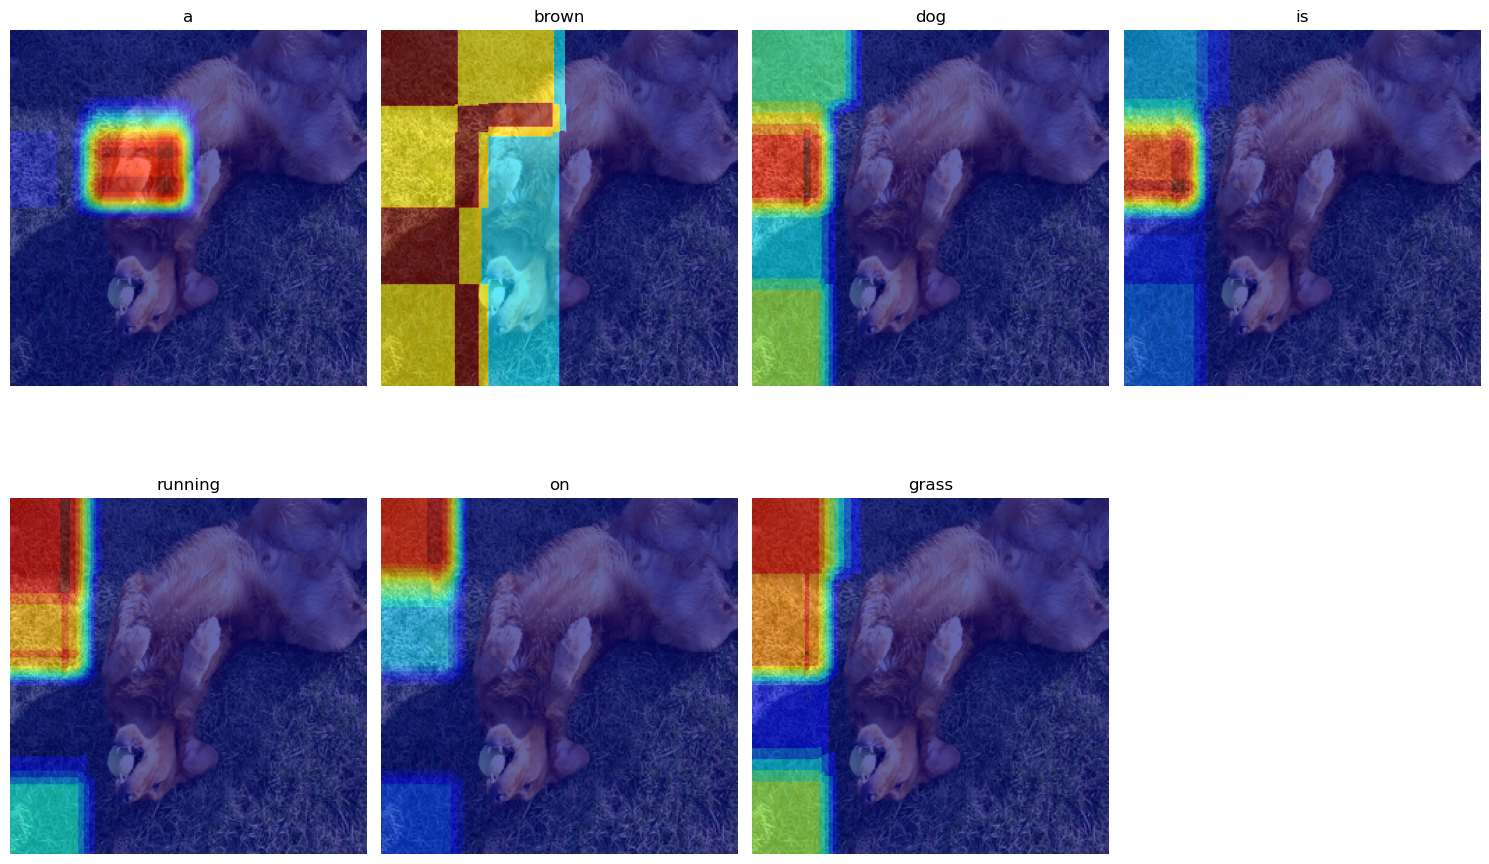

In [49]:
img_id = selected_imgs[0]
img_path = os.path.join(image_dir, img_id)
image_tensor = transform(Image.open(img_path).convert("RGB")).to(device)

caption, alphas = generate_caption_with_attention(image_tensor)
print("🧠 Caption générée :", " ".join(caption))
visualize_attention(img_path, caption, alphas)
